# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to analyze the processed sales data, identify business patterns, and generate insights that support accurate sales forecasting.

The analysis focuses on:

- Sales behavior over time.
- Product performance.
- Store and state performance.
- Weekly sales patterns.
- Business insights for forecasting.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Better looking plots
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
# Project Color Palette
BLUE = "#4E79A7"
ORANGE = "#F28E2B"
GREEN = "#59A14F"

CATEGORY_COLORS = {
    "FOODS": BLUE,
    "HOUSEHOLD": ORANGE,
    "HOBBIES": GREEN
}

STATE_COLORS = {
    "CA": BLUE,
    "WI": ORANGE,
    "TX": GREEN
}

## 1. Monthly Sales Trend

### Business Question

How do total sales change over time?

This analysis helps identify long-term trends and seasonal patterns that may influence forecasting.

In [3]:
monthly_sales = pd.read_parquet(
    "../data/analysis/monthly_sales.parquet"
)

monthly_sales.head()

,year,month,total_sales
0,2013,5,267026
1,2013,6,1135593
2,2013,7,1159467
3,2013,8,1204813
4,2013,9,1166515


In [4]:
monthly_sales.shape

(37, 3)

In [5]:
monthly_sales_filtered = monthly_sales.iloc[1:-1]

monthly_sales_filtered

,year,month,total_sales
1,2013,6,1135593
2,2013,7,1159467
3,2013,8,1204813
4,2013,9,1166515
5,2013,10,1124523
6,2013,11,1044799
7,2013,12,1054534
8,2014,1,1057012
9,2014,2,1009760
10,2014,3,1123706


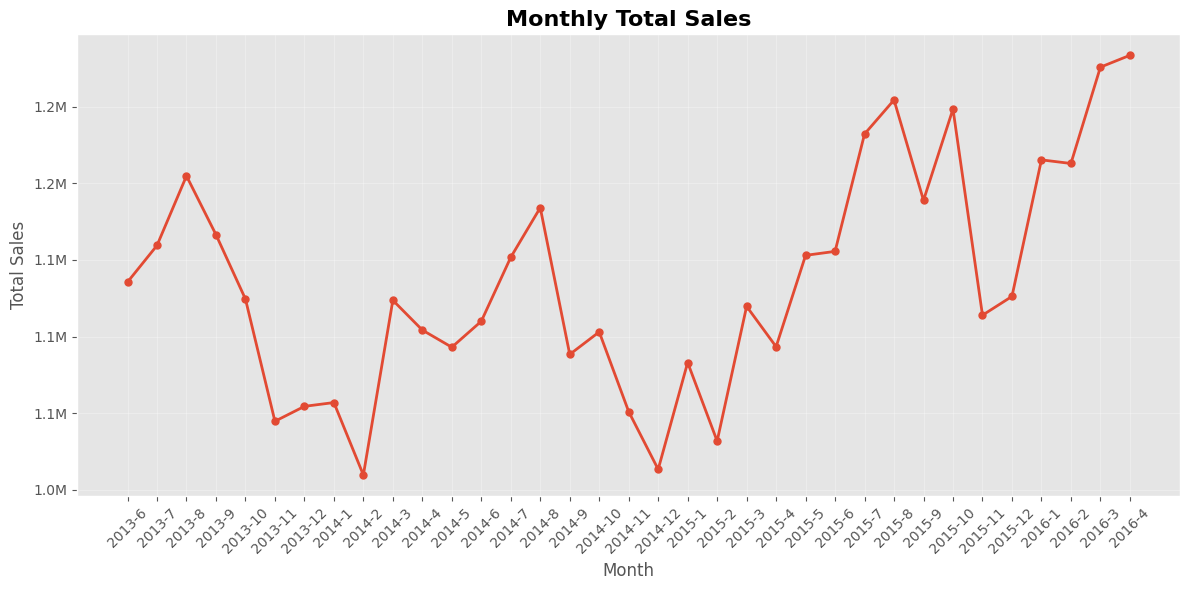

In [6]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales_filtered["year"].astype(str) + "-" +
    monthly_sales_filtered["month"].astype(str),
    monthly_sales_filtered["total_sales"],
    marker="o",
    linewidth=2,
    markersize=5
)

plt.title("Monthly Total Sales", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

# Display values in millions
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M")
)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Business Insights

- Monthly sales show a gradual upward trend over the analyzed period.
- Sales exhibit seasonal fluctuations rather than remaining constant throughout the year.
- Month-to-month variability suggests that external factors such as promotions, holidays, and customer behavior influence demand.
- No major structural breaks or abnormal changes were observed, indicating consistent sales behavior over the selected period.

### Impact on Forecasting

The observed trend and seasonality suggest that time-based features (such as month, lag variables, and rolling statistics) will be important for improving forecasting accuracy.

## 2. Category Sales Analysis

### Business Question

Which product categories generate the highest total sales?

Understanding category performance helps identify the primary drivers of revenue and demand.

In [7]:
category_sales = pd.read_parquet(
    "../data/analysis/category_sales.parquet"
)

category_sales

,cat_id,total_sales
0,FOODS,27616083
1,HOUSEHOLD,9518699
2,HOBBIES,3895486


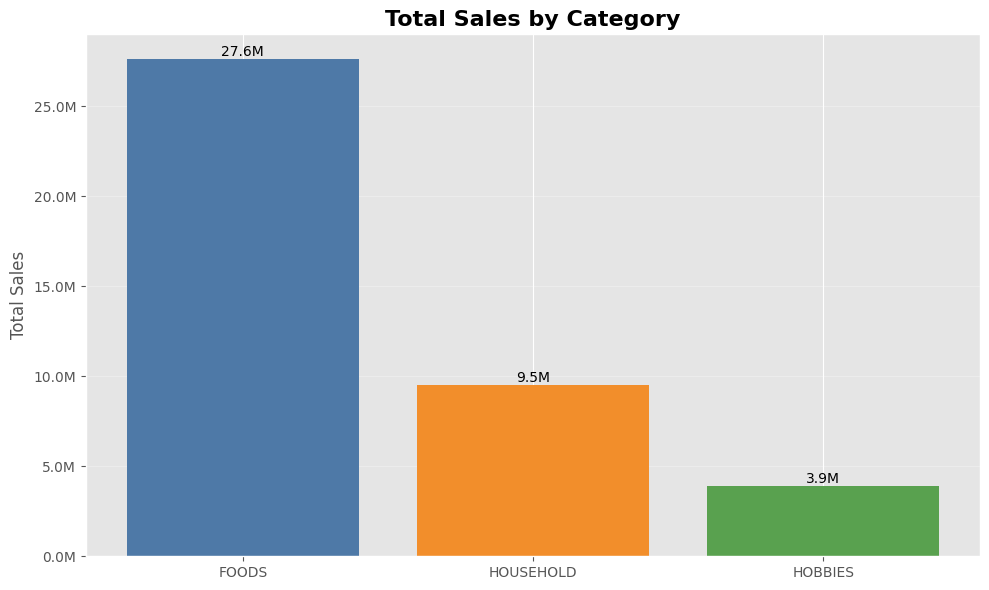

In [8]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))

bars = plt.bar(
    category_sales["cat_id"],
    category_sales["total_sales"],
    color=["#4E79A7", "#F28E2B", "#59A14F"]
)

plt.title("Total Sales by Category", fontsize=16, fontweight="bold")
plt.ylabel("Total Sales", fontsize=12)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M")
)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Business Insights

- The FOODS category contributes the highest total sales by a large margin.
- HOUSEHOLD is the second-largest contributor.
- HOBBIES has the lowest sales volume.

### Impact on Forecasting

The large differences between categories indicate that product category is an important predictor of demand. Category-related features should therefore be included during feature engineering.

## 3. Department Sales Analysis

### Business Question

Which departments contribute the most sales within each product category?

Analyzing departments provides a more detailed understanding of product performance than category-level analysis alone.

In [9]:
department_sales = pd.read_parquet(
    "../data/analysis/department_sales.parquet"
)

department_sales

,cat_id,dept_id,total_sales
0,FOODS,FOODS_3,19690227
1,HOUSEHOLD,HOUSEHOLD_1,7638252
2,FOODS,FOODS_2,4762647
3,HOBBIES,HOBBIES_1,3530387
4,FOODS,FOODS_1,3163209
5,HOUSEHOLD,HOUSEHOLD_2,1880447
6,HOBBIES,HOBBIES_2,365099


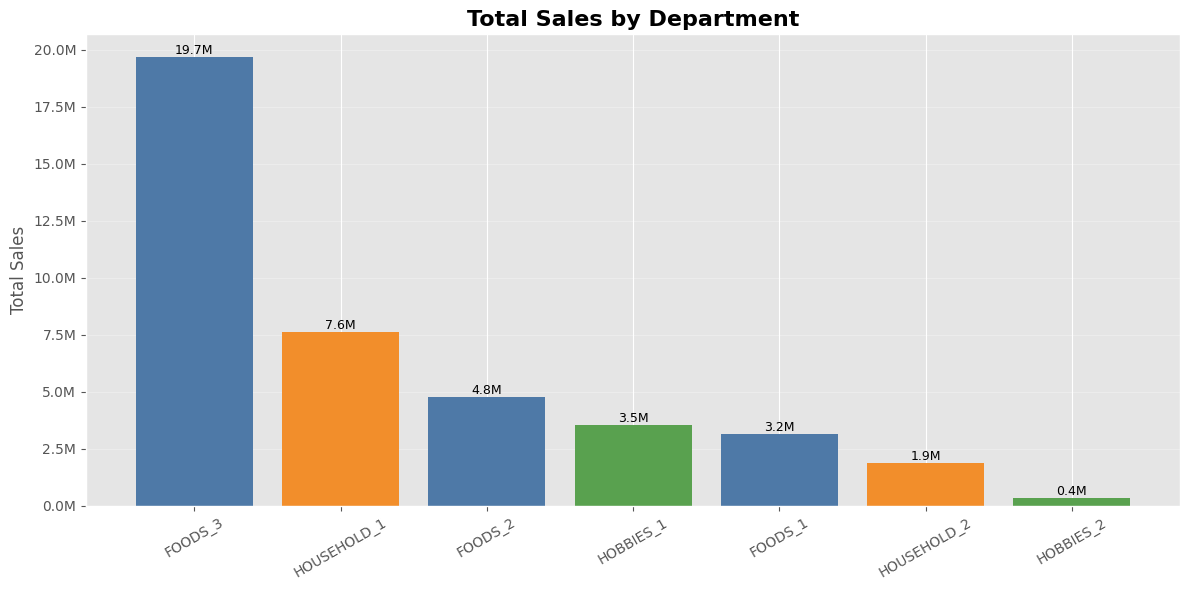

In [10]:
plt.figure(figsize=(12,6))

color_map = {
    "FOODS": "#4E79A7",
    "HOUSEHOLD": "#F28E2B",
    "HOBBIES": "#59A14F"
}

colors = department_sales["cat_id"].map(color_map)

bars = plt.bar(
    department_sales["dept_id"],
    department_sales["total_sales"],
    color=colors
)

plt.title("Total Sales by Department", fontsize=16, fontweight="bold")
plt.ylabel("Total Sales", fontsize=12)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M")
)

plt.xticks(rotation=30)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Business Insights

- FOODS_3 is the highest-performing department by a substantial margin.
- The FOODS category performs well across multiple departments, indicating consistently strong demand.
- HOUSEHOLD_1 is the strongest non-food department.
- HOBBIES_2 contributes the lowest sales, suggesting relatively weak customer demand.

### Impact on Forecasting

The large differences in demand across departments indicate that department-level information should be included as a predictive feature. Products from different departments exhibit distinct sales behaviors that the forecasting model should learn.

## 4. Store Sales Analysis

### Business Question

Which stores generate the highest total sales?

Analyzing store performance helps identify the strongest and weakest locations and reveals differences in customer demand across stores.

In [11]:
store_sales = pd.read_parquet(
    "../data/analysis/store_sales.parquet"
)

store_sales

,state_id,store_id,total_sales
0,CA,CA_3,6919055
1,CA,CA_1,4809909
2,WI,WI_2,4561984
3,TX,TX_2,4220301
4,TX,TX_3,3840394
5,WI,WI_1,3608841
6,CA,CA_2,3544360
7,WI,WI_3,3506042
8,TX,TX_1,3406048
9,CA,CA_4,2613334


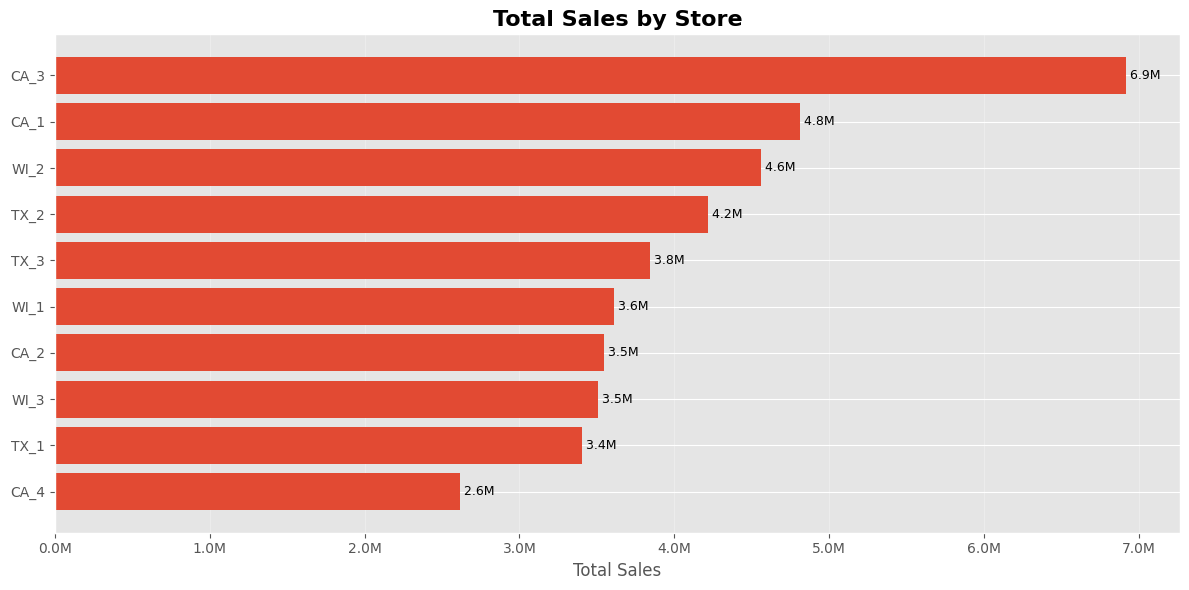

In [12]:
plt.figure(figsize=(12,6))

bars = plt.barh(
    store_sales["store_id"],
    store_sales["total_sales"]
)

plt.title("Total Sales by Store", fontsize=16, fontweight="bold")
plt.xlabel("Total Sales", fontsize=12)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M")
)

# Highest sales at the top
plt.gca().invert_yaxis()

# Value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f" {width/1e6:.1f}M",
        va="center",
        fontsize=9
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Business Insights

- CA_3 generated the highest total sales among all stores.
- CA_4 recorded the lowest total sales.
- Sales vary substantially across stores, even within the same state.
- The best-performing store generated approximately 2.7 times the sales of the lowest-performing store.

### Impact on Forecasting

The large differences in sales across stores indicate that `store_id` is an important predictive feature. Forecasting models should account for store-specific demand patterns rather than assuming all stores behave similarly.

## 5. State Sales Analysis

### Business Question

Which states generate the highest total sales?

State-level analysis provides a broader geographical view of sales performance and helps identify regional demand patterns.

In [13]:
state_sales = pd.read_parquet(
    "../data/analysis/state_sales.parquet"
)

state_sales.head()

,state_id,total_sales
0,CA,17886658
1,WI,11676867
2,TX,11466743


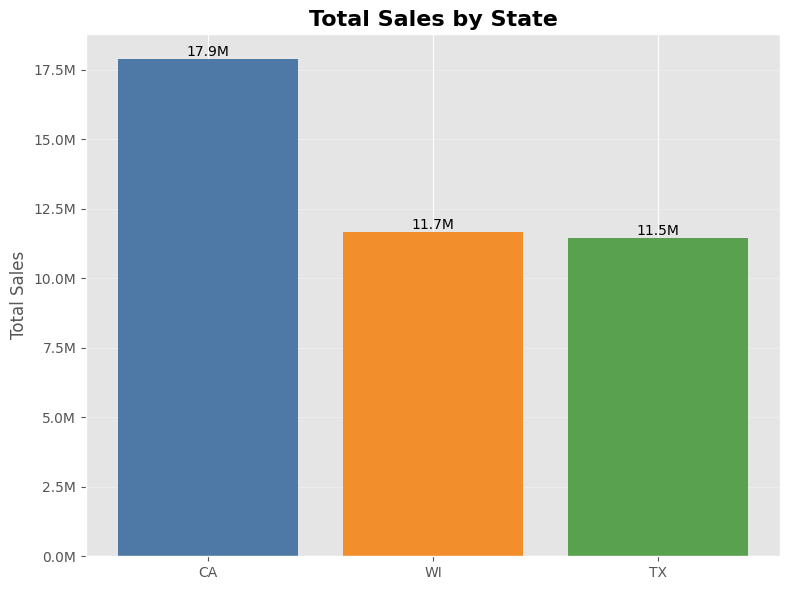

In [14]:
plt.figure(figsize=(8,6))

colors = ["#4E79A7", "#F28E2B", "#59A14F"]

bars = plt.bar(
    state_sales["state_id"],
    state_sales["total_sales"],
    color=colors
)

plt.title("Total Sales by State", fontsize=16, fontweight="bold")
...
plt.ylabel("Total Sales", fontsize=12)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M")
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Weekday Sales Analysis

### Business Question

How do total sales vary across different days of the week?

Understanding weekly sales patterns helps identify recurring customer purchasing behavior and determine whether demand changes depending on the day of the week.

In [16]:
weekday_sales = pd.read_parquet(
    "../data/analysis/weekday_sales.parquet"
)

weekday_sales

,wday,weekday,total_sales
0,1,Saturday,7064159
1,2,Sunday,7095934
2,3,Monday,5612686
3,4,Tuesday,5201675
4,5,Wednesday,5108961
5,6,Thursday,5136327
6,7,Friday,5810526


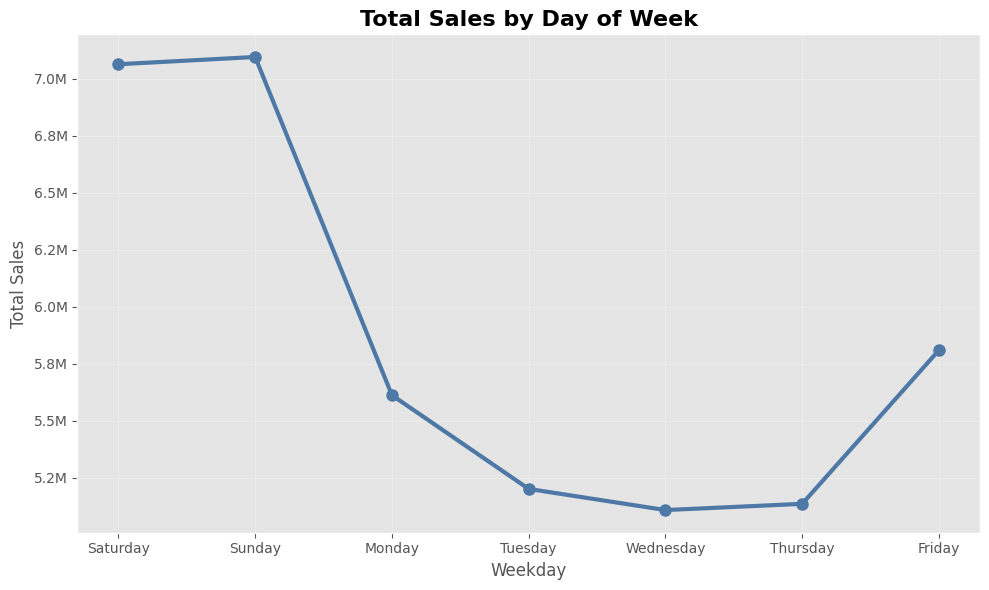

In [17]:
plt.figure(figsize=(10,6))

plt.plot(
    weekday_sales["weekday"],
    weekday_sales["total_sales"],
    marker="o",
    linewidth=3,
    markersize=8,
    color=BLUE
)

plt.title("Total Sales by Day of Week", fontsize=16, fontweight="bold")
plt.xlabel("Weekday", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M")
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Business Insights

- Weekend sales (Saturday and Sunday) are the highest, with Sunday recording the maximum demand.
- Sales decrease noticeably after the weekend and remain relatively low during the middle of the week.
- Demand starts to recover on Friday before increasing again during the weekend.
- Weekly sales exhibit a clear and recurring seasonal pattern.

### Impact on Forecasting

The observed weekly seasonality indicates that the day of the week influences customer demand. Time-based features such as `weekday` should therefore be included in the forecasting model.

# Exploratory Data Analysis Summary

The exploratory data analysis revealed several important sales patterns within the dataset.

Sales increased gradually over time, indicating an overall positive trend. Product performance was highly uneven, with the **FOODS** category and **FOODS_3** department contributing the largest share of total sales. Store-level analysis showed substantial variation in demand across locations, while California generated the highest overall sales among the three states.

Weekly analysis also revealed clear seasonality, with customer demand peaking during weekends and decreasing throughout the work week.

These findings demonstrate that temporal variables (date, month, weekday), geographical information (state and store), and product hierarchy (category and department) all influence demand. These insights will guide the feature engineering process and improve the performance of the forecasting models developed in the next stage of the project.